In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
from matplotlib import cm
from tqdm import tqdm
import os
import torch
torch.cuda.empty_cache()
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from numpy import linalg as la
from numpy import *
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
# from solver_sdmd_torch_gpu import KoopmanNNTorch, KoopmanSolverTorch


print (torch.__version__, torch.cuda.is_available())
print(torch.version.cuda)
print (torch.cuda.get_device_name())
# device= 'cpu'
device= 'cuda'

2.3.1 True
11.8
NVIDIA GeForce RTX 3070 Ti


In [2]:
torch.cuda.empty_cache()

In [3]:
#### Test 2 ####
## Define the potential function V(x, y) and plot the potential landscape
def potential(x, y):
    return (
        3 * np.exp(-x**2 - (y - 1/3)**2)
        - 3 * np.exp(-x**2 - (y - 5/3)**2)
        - 5 * np.exp(-(x - 1)**2 - y**2)
        - 5 * np.exp(-(x + 1)**2 - y**2)
        + 0.2 * x**4
        + 0.2 * (y - 1/3)**4
    )

# Define the gradient of the potential function
def gradient(x, y):
    dVdx = (
        -6 * x * np.exp(-x**2 - (y - 1/3)**2)
        + 6 * x * np.exp(-x**2 - (y - 5/3)**2)
        + 10 * (x - 1) * np.exp(-(x - 1)**2 - y**2)
        + 10 * (x + 1) * np.exp(-(x + 1)**2 - y**2)
        + 0.8 * x**3
    )
    dVdy = (
        -6 * (y - 1/3) * np.exp(-x**2 - (y - 1/3)**2)
        + 6 * (y - 5/3) * np.exp(-x**2 - (y - 5/3)**2)
        + 10 * y * np.exp(-(x - 1)**2 - y**2)
        + 10 * y * np.exp(-(x + 1)**2 - y**2)
        + 0.8 * (y - 1/3)**3
    )
    return dVdx, dVdy

## Generate m^2 trajectories in the landscape
# Set the parameters for the SDE
#h = 1e-3  # Integration step size
h = 1e-3  # Integration step size
#h = 1e-5  # Integration step size
n_steps = 100  # Number of integration steps between each evaluation
n_eval = 10  # Number of evaluations
lag_time = h * n_steps  # Lag time

# Set the number of points to select in each dimension
m = 35

# Set the diffusion coefficient
sigma = 1.09
print ('Lag time: ', lag_time)



# Generate linspace for x and y coordinates
x_values = np.linspace(-2, 2, m)
y_values = np.linspace(-1, 2, m)

# Create a meshgrid from these linspace arrays
xx, yy = np.meshgrid(x_values, y_values)

# Flatten the meshgrid matrices to get the coordinate pairs
x0_values = xx.flatten()
y0_values = yy.flatten()

# Initialize the data_matrix
data_matrix = np.zeros((m**2, n_eval+1, 2))

# Generate trajectories for each selected point
for i in tqdm (range(m**2)):
    x = x0_values[i]
    y = y0_values[i]
    
    for j in range(n_eval+1):
        data_matrix[i, j, 0] = x
        data_matrix[i, j, 1] = y
        
        for k in range(n_steps):
            dVdx, dVdy = gradient(x, y)
            x += -dVdx * h + sigma * np.sqrt(h) * np.random.normal()
            y += -dVdy * h + sigma * np.sqrt(h) * np.random.normal()

# Create a grid of points
x_plot = np.linspace(-2, 2, 100)
y_plot = np.linspace(-1, 2, 100)
X, Y = np.meshgrid(x_plot, y_plot)



# Extract data_X and data_Y from the data matrix
data_X = data_matrix[:, :-1, :]
data_Y = data_matrix[:, 1:, :]
print(f"Shape of data_X: {data_X.shape}")
print(f"Shape of data_Y: {data_Y.shape}")

# Reshape data_X and data_Y into a single column
X = data_X.reshape(-1, data_X.shape[2])  # 2D features
Y = data_Y.reshape(-1, data_X.shape[2])  # 2D targets
print(f"Shape of X: {X.shape}")
print(f"Shape of Y: {Y.shape}")

# Separate data into two parts: train and validation
len_all = X.shape[0]
data_x_train = X[:int(0.7*len_all)]
data_x_valid = X[int(0.7*len_all)+1:]

data_y_train = Y[:int(0.7*len_all)]
data_y_valid = Y[int(0.7*len_all)+1:]

data_train = [data_x_train, data_y_train]
data_valid = [data_x_valid, data_y_valid]

print(data_x_train.shape)


Lag time:  0.1


100%|██████████| 1225/1225 [00:16<00:00, 74.46it/s]

Shape of data_X: (1225, 10, 2)
Shape of data_Y: (1225, 10, 2)
Shape of X: (12250, 2)
Shape of Y: (12250, 2)
(8575, 2)


Outer Epoch 1/6
Epoch: 1 	Training Loss: 0.020264 val loss: 0.025599
saving, val loss enhanced: 0.025598749352765827 1000000000000000.0
Epoch: 2 	Training Loss: 0.020247 val loss: 0.025584
saving, val loss enhanced: 0.025584121561825483 0.025598749352765827
Epoch: 3 	Training Loss: 0.020235 val loss: 0.025616
Outer Epoch 2/6
Epoch: 1 	Training Loss: 0.020216 val loss: 0.025539
saving, val loss enhanced: 0.025538870271036934 0.025584121561825483
Epoch: 2 	Training Loss: 0.020202 val loss: 0.025542
Epoch: 3 	Training Loss: 0.020188 val loss: 0.025608
Outer Epoch 3/6
Epoch: 1 	Training Loss: 0.020169 val loss: 0.025547
Epoch: 2 	Training Loss: 0.020154 val loss: 0.025510
saving, val loss enhanced: 0.025510333770454918 0.025538870271036934
Epoch: 3 	Training Loss: 0.020141 val loss: 0.025498
saving, val loss enhanced: 0.025497775441968382 0.025510333770454918
Outer Epoch 4/6
Epoch: 1 	Training Loss: 0.020124 val loss: 0.025465
saving, val loss enhanced: 0.025465274107837246 0.0254977754419

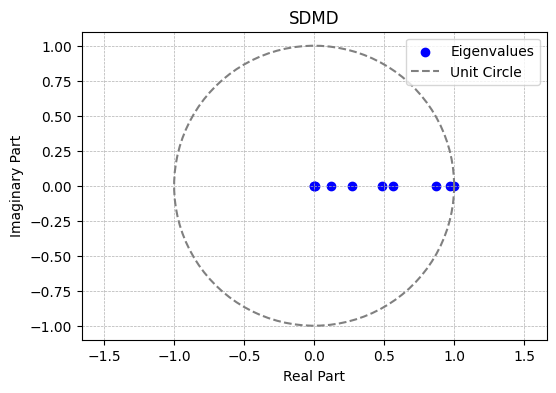

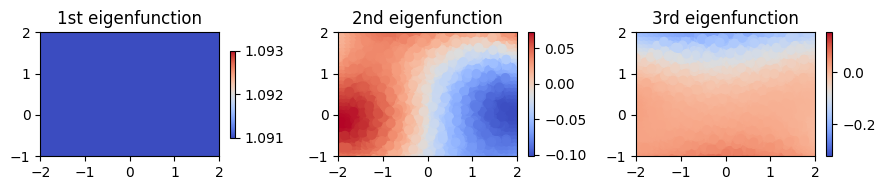

In [4]:
from solver_edmd_torch_gpu import KoopmanNNTorch, EDMDSolverTorch
#### EDMD Test ####
checkpoint_file= 'well2d_example_ckpt001_e.torch'

basis_function = KoopmanNNTorch(input_size= 2, layer_sizes=[10], n_psi_train=7).to(device)

solver = EDMDSolverTorch(
    dic=basis_function,
    target_dim=np.shape(data_x_train)[-1],
    reg=0.1,
    checkpoint_file=checkpoint_file,
    batch_size=32
)

data_x_train_tensor = torch.DoubleTensor(data_x_train).to (device)#, requieres_grad= True)#, dtype=tf.float64)
data_y_train_tensor = torch.DoubleTensor(data_y_train).to (device)#, requires_grad= True)#, dtype=tf.float64)

solver.build_with_edmd(
    data_train=data_train,
    data_valid=data_valid,
    epochs=6,
    batch_size=256,
    lr=1e-5,
    log_interval=10,
    lr_decay_factor=0.8
)

# Results from solver_edmd
evalues = solver.eigenvalues.T
efuns = solver.eigenfunctions(X)
N_dict = np.shape(evalues)[0]
Koopman_matrix_K = solver.K
outputs = {
    'efuns': efuns,
    'evalues': evalues,
    'N_dict': N_dict,
    # 'K': Koopman_matrix_K
    }

# Assuming 'efuns' is a 2D numpy array with shape (n_samples, n_eigenfunctions)
# and 'X' is a 2D numpy array with shape (n_samples, 2) representing your input data

# Assuming evalues is a numpy array of complex numbers
print(evalues.shape)
print(evalues)

# Plot eigenvalues on unit circle
real_parts = evalues.real
imag_parts = evalues.imag

# Create the plot
plt.figure(figsize=(6, 4))
plt.scatter(real_parts, imag_parts, color='blue', label='Eigenvalues')

# Draw a unit circle for reference
theta = np.linspace(0, 2 * np.pi, 100)
plt.plot(np.cos(theta), np.sin(theta), linestyle='--', color='grey', label='Unit Circle')

plt.title('SDMD')
plt.xlabel('Real Part')
plt.ylabel('Imaginary Part')
plt.axis('equal')  # Ensure the aspect ratio is equal to make the unit circle round
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend()
plt.show()

# Plot eigenfunctions
fig, axs = plt.subplots(1, 3, figsize=(9, 2))

# Plot for the 1st eigenfunction
# scatter1 = axs[0].scatter(*X.T, c=np.real(efuns)[:, 0], cmap='coolwarm')
scatter1 = axs[0].scatter(*X.T, c=np.real(efuns)[:, 0], cmap='coolwarm', vmin=1.091, vmax=1.093)
axs[0].set_title('1st eigenfunction')
axs[0].set_xlim(-2, 2)
axs[0].set_ylim(-1, 2)
cbar1 = fig.colorbar(scatter1, ax=axs[0], shrink=0.7, aspect=20)

# Plot for the 2nd eigenfunction
scatter2 = axs[1].scatter(*X.T, c=np.real(efuns)[:, 1], cmap='coolwarm')
axs[1].set_title('2nd eigenfunction')
axs[1].set_xlim(-2, 2)
axs[1].set_ylim(-1, 2)
cbar2 = fig.colorbar(scatter2, ax=axs[1])

# Plot for the 3rd eigenfunction
scatter3 = axs[2].scatter(*X.T, c=np.real(efuns)[:, 2], cmap='coolwarm')
axs[2].set_title('3rd eigenfunction')
axs[2].set_xlim(-2, 2)
axs[2].set_ylim(-1, 2)
cbar3 = fig.colorbar(scatter3, ax=axs[2])

# # Plot for the 4th eigenfunction
# scatter4 = axs[3].scatter(*X.T, c=np.real(efuns)[:, 3], cmap='coolwarm')
# axs[3].set_title('4th eigenfunction')
# axs[3].set_xlim(-2, 2)
# axs[3].set_ylim(-1, 2)
# cbar4 = fig.colorbar(scatter4, ax=axs[3])

# fig.suptitle(' SDMD ', fontsize=16)
plt.tight_layout()
plt.show()

Epoch: 1 	Training Loss: 0.208042 	Validation Loss: 0.128873
Saving model, validation loss improved: 0.128873 < 10000.000000
Epoch: 2 	Training Loss: 0.126356 	Validation Loss: 0.125533
Saving model, validation loss improved: 0.125533 < 0.128873
Epoch: 3 	Training Loss: 0.124658 	Validation Loss: 0.124181
Saving model, validation loss improved: 0.124181 < 0.125533
Epoch: 4 	Training Loss: 0.123803 	Validation Loss: 0.124413
Epoch: 5 	Training Loss: 0.123786 	Validation Loss: 0.123040
Saving model, validation loss improved: 0.123040 < 0.124181
Epoch: 6 	Training Loss: 0.123377 	Validation Loss: 0.123079
Epoch: 7 	Training Loss: 0.122877 	Validation Loss: 0.122336
Saving model, validation loss improved: 0.122336 < 0.123040
Epoch: 8 	Training Loss: 0.122525 	Validation Loss: 0.121656
Saving model, validation loss improved: 0.121656 < 0.122336
Epoch: 9 	Training Loss: 0.122108 	Validation Loss: 0.121695
Epoch: 10 	Training Loss: 0.122287 	Validation Loss: 0.121522
Saving model, validation 

Processing batches:   0%|          | 0/134 [00:00<?, ?batch/s]c:\Users\xyc93\AppData\Local\anaconda3\envs\myvenvtorch\lib\site-packages\torch\_functorch\deprecated.py:61: UserWarning: We've integrated functorch into PyTorch. As the final step of the integration, functorch.vmap is deprecated as of PyTorch 2.0 and will be deleted in a future version of PyTorch >= 2.3. Please use torch.vmap instead; see the PyTorch 2.0 release notes and/or the torch.func migration guide for more details https://pytorch.org/docs/master/func.migrating.html
  warn_deprecated('vmap', 'torch.vmap')
Processing batches: 100%|██████████| 134/134 [00:00<00:00, 262.98batch/s]


saving FNN a and b to:  a_b_example_3ple_well.jbl
Outer Epoch 1/6


Processing batches: 100%|██████████| 134/134 [00:00<00:00, 251.48batch/s]
c:\Users\xyc93\AppData\Local\anaconda3\envs\myvenvtorch\lib\site-packages\torch\optim\lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


Epoch: 1 	Training Loss: 0.030481 val loss: 0.036206
Saving model, val loss improved from 1000000000000000.000000 to 0.036206
Epoch: 2 	Training Loss: 0.030296 val loss: 0.036045
Saving model, val loss improved from 0.036206 to 0.036045
Epoch 1 time: 0.97 seconds
Outer Epoch 2/6


...

Epoch: 1 	Training Loss: 0.030467 val loss: 0.036198
Epoch: 2 	Training Loss: 0.030284 val loss: 0.036037
Epoch 4 time: 1.02 seconds
Outer Epoch 5/6


Processing batches: 100%|██████████| 134/134 [00:00<00:00, 242.88batch/s]


Epoch: 1 	Training Loss: 0.030468 val loss: 0.036200
Epoch: 2 	Training Loss: 0.030284 val loss: 0.036038
Epoch 5 time: 0.97 seconds
Outer Epoch 6/6


Processing batches: 100%|██████████| 134/134 [00:00<00:00, 246.53batch/s]


Epoch: 1 	Training Loss: 0.030467 val loss: 0.036199
Epoch: 2 	Training Loss: 0.030284 val loss: 0.036037
Epoch 6 time: 0.96 seconds
(10,)
[0.99999978+0.j         0.99205322+0.j         0.88967562+0.j
 0.55247754-0.00380879j 0.55247754+0.00380879j 0.35847707+0.j
 0.26701639+0.j         0.08792733+0.j         0.0318458 +0.j
 0.00795102+0.j        ]


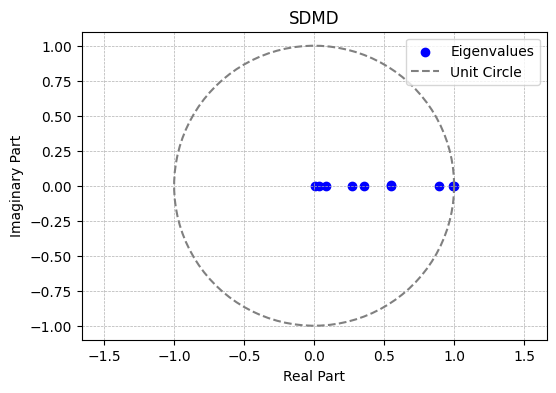

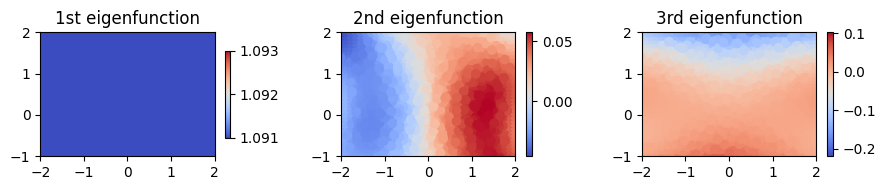

In [5]:
from solver_sdmd_torch_gpu2 import KoopmanNNTorch, KoopmanSolverTorch
#### SDMD Test ####
checkpoint_file= 'well2d_example_ckpt001_s.torch'

basis_function = KoopmanNNTorch(input_size= 2, layer_sizes=[10], n_psi_train=7).to(device)  # basis number would be 20


solver = KoopmanSolverTorch(dic=basis_function, # Replace 'koopman_nn' by 'dic' if you use the original solver_edmdvar
                       target_dim=np.shape(data_x_train)[-1],
                                                   reg=0.1,  checkpoint_file= checkpoint_file, fnn_checkpoint_file= 'example_fnn001.torch', 
                            a_b_file= 'a_b_example_3ple_well.jbl', 
                        generator_batch_size= 2, fnn_batch_size= 32, delta_t= lag_time)

solver.build_with_generator(
    data_train=data_train,
    data_valid=data_valid,
    epochs=6,
    batch_size=256,
    lr=1e-5,
    log_interval=10,
    lr_decay_factor=.8
    )

# Results from solver_edmd/solver_resdmd
evalues = solver.eigenvalues.T
efuns = solver.eigenfunctions(X)
#kpm_modes = solver.compute_mode().T
N_dict = np.shape(evalues)[0]
Psi_X = solver.get_Psi_X()
Psi_Y = solver.get_Psi_Y()
Koopman_matrix_K = solver.K

outputs = {
    'efuns': efuns,
    'evalues': evalues,
    # 'kpm_modes': kpm_modes,
    'N_dict': N_dict,
    # 'K': Koopman_matrix_K,
    # 'Psi_X': Psi_X,
    # 'Psi_Y': Psi_Y,
    }



# Assuming 'efuns' is a 2D numpy array with shape (n_samples, n_eigenfunctions)
# and 'X' is a 2D numpy array with shape (n_samples, 2) representing your input data

# Assuming evalues is a numpy array of complex numbers
print(evalues.shape)
print(evalues)

# Plot eigenvalues on unit circle
real_parts = evalues.real
imag_parts = evalues.imag

# Create the plot
plt.figure(figsize=(6, 4))
plt.scatter(real_parts, imag_parts, color='blue', label='Eigenvalues')

# Draw a unit circle for reference
theta = np.linspace(0, 2 * np.pi, 100)
plt.plot(np.cos(theta), np.sin(theta), linestyle='--', color='grey', label='Unit Circle')

plt.title('SDMD')
plt.xlabel('Real Part')
plt.ylabel('Imaginary Part')
plt.axis('equal')  # Ensure the aspect ratio is equal to make the unit circle round
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend()
plt.show()

# Plot eigenfunctions
fig, axs = plt.subplots(1, 3, figsize=(9, 2))

# Plot for the 1st eigenfunction
# scatter1 = axs[0].scatter(*X.T, c=np.real(efuns)[:, 0], cmap='coolwarm')
scatter1 = axs[0].scatter(*X.T, c=np.real(efuns)[:, 0], cmap='coolwarm', vmin=1.091, vmax=1.093)
axs[0].set_title('1st eigenfunction')
axs[0].set_xlim(-2, 2)
axs[0].set_ylim(-1, 2)
cbar1 = fig.colorbar(scatter1, ax=axs[0], shrink=0.7, aspect=20)

# Plot for the 2nd eigenfunction
scatter2 = axs[1].scatter(*X.T, c=np.real(efuns)[:, 1], cmap='coolwarm')
axs[1].set_title('2nd eigenfunction')
axs[1].set_xlim(-2, 2)
axs[1].set_ylim(-1, 2)
cbar2 = fig.colorbar(scatter2, ax=axs[1])

# Plot for the 3rd eigenfunction
scatter3 = axs[2].scatter(*X.T, c=np.real(efuns)[:, 2], cmap='coolwarm')
axs[2].set_title('3rd eigenfunction')
axs[2].set_xlim(-2, 2)
axs[2].set_ylim(-1, 2)
cbar3 = fig.colorbar(scatter3, ax=axs[2])

# # Plot for the 4th eigenfunction
# scatter4 = axs[3].scatter(*X.T, c=np.real(efuns)[:, 3], cmap='coolwarm')
# axs[3].set_title('4th eigenfunction')
# axs[3].set_xlim(-2, 2)
# axs[3].set_ylim(-1, 2)
# cbar4 = fig.colorbar(scatter4, ax=axs[3])

# fig.suptitle(' SDMD ', fontsize=16)
plt.tight_layout()
plt.show()

In [6]:
del solver, basis_function
torch.cuda.empty_cache()

Epoch: 1 	Training Loss: 0.232574 	Validation Loss: 0.128174
Saving model, validation loss improved: 0.128174 < 10000.000000
Epoch: 2 	Training Loss: 0.125996 	Validation Loss: 0.127101
Saving model, validation loss improved: 0.127101 < 0.128174
Epoch: 3 	Training Loss: 0.125033 	Validation Loss: 0.125023
Saving model, validation loss improved: 0.125023 < 0.127101
Epoch: 4 	Training Loss: 0.123936 	Validation Loss: 0.125116
Epoch: 5 	Training Loss: 0.123544 	Validation Loss: 0.123976
Saving model, validation loss improved: 0.123976 < 0.125023
Epoch: 6 	Training Loss: 0.123145 	Validation Loss: 0.123733
Saving model, validation loss improved: 0.123733 < 0.123976
Epoch: 7 	Training Loss: 0.122770 	Validation Loss: 0.122886
Saving model, validation loss improved: 0.122886 < 0.123733
Epoch: 8 	Training Loss: 0.122547 	Validation Loss: 0.123311
Epoch: 9 	Training Loss: 0.122228 	Validation Loss: 0.122580
Saving model, validation loss improved: 0.122580 < 0.122886
Epoch: 10 	Training Loss: 0

Processing batches: 100%|██████████| 134/134 [00:00<00:00, 273.37batch/s]


Epoch 1/6, gEDMD loss: 4.023782e-02
Saving best model at epoch 1


Processing batches: 100%|██████████| 134/134 [00:00<00:00, 274.69batch/s]


EarlyStopping counter: 1 out of 7


...

EarlyStopping counter: 3 out of 7


Processing batches: 100%|██████████| 134/134 [00:00<00:00, 271.30batch/s]


EarlyStopping counter: 4 out of 7


Processing batches: 100%|██████████| 134/134 [00:00<00:00, 268.45batch/s]


EarlyStopping counter: 5 out of 7
(10,)
[1.        +0.j         1.11541088+0.j         1.03300835+0.08475837j
 1.03300835-0.08475837j 1.01674883+0.01890142j 1.01674883-0.01890142j
 0.98191835+0.01795053j 0.98191835-0.01795053j 0.99922123+0.j
 1.00081922+0.j        ]


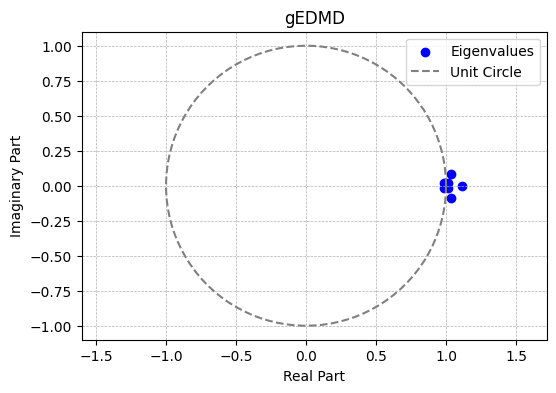

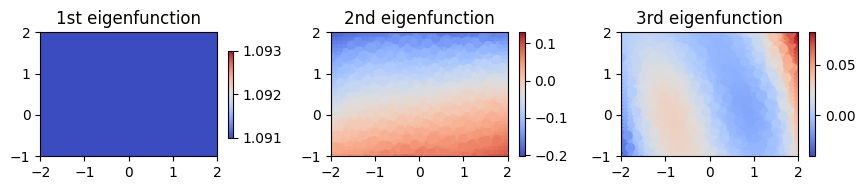

In [7]:
from solver_gedmd_torch_gpu import KoopmanSolverTorch as KoopmanSolverTorch_g
#### gEDMD Test ####
checkpoint_file_g= 'well2d_example_ckpt001_g.torch'

basis_function_g = KoopmanNNTorch(input_size= 2, layer_sizes=[10], n_psi_train=7).to(device)  # basis number would be 20


solver_g = KoopmanSolverTorch_g(dic=basis_function_g, # Replace 'koopman_nn' by 'dic' if you use the original solver_edmdvar
                       target_dim=np.shape(data_x_train)[-1],
                                                   reg=0.1,  checkpoint_file= checkpoint_file_g, fnn_checkpoint_file= 'example_fnn001.torch', 
                            a_b_file= 'a_b_example_3ple_well.jbl', 
                        generator_batch_size= 2, fnn_batch_size= 32)

solver_g.build_with_generator(
    data_train=data_train,
    data_valid=data_valid,
    epochs=6,
    batch_size=256,
    lr=1e-5,
    log_interval=10,
    lr_decay_factor=.8
    )

solver_g.eig_decomp()  # Do spectral decomposition to generate eigenvalues and eigenvectors

# Results from solver_gedmd
evalues = solver_g.eigenvalues.T
efuns = solver_g.eigenfunctions(X)
#kpm_modes = solver.compute_mode().T
N_dict = np.shape(evalues)[0]
Psi_X = solver_g.get_Psi_X()
Psi_Y = solver_g.get_Psi_Y()


outputs = {
    'efuns': efuns,
    'evalues': evalues,
    # 'kpm_modes': kpm_modes,
    'N_dict': N_dict,
    # 'K': Koopman_matrix_K,
    # 'Psi_X': Psi_X,
    # 'Psi_Y': Psi_Y,
    }



# computing eigenvalues of K from generator eigenvalues using exponetnt
# eigenfunctions are the same for the operator and the generator
evalues_K = np.exp(evalues * lag_time)

# Assuming 'efuns' is a 2D numpy array with shape (n_samples, n_eigenfunctions)
# and 'X' is a 2D numpy array with shape (n_samples, 2) representing your input data
# Assuming evalues is a numpy array of complex numbers

print(evalues_K.shape)
print(evalues_K)

# Plot eigenvalues on unit circle
real_parts = evalues_K.real
imag_parts = evalues_K.imag

# Create the plot
plt.figure(figsize=(6, 4))
plt.scatter(real_parts, imag_parts, color='blue', label='Eigenvalues')

# Draw a unit circle for reference
theta = np.linspace(0, 2 * np.pi, 100)
plt.plot(np.cos(theta), np.sin(theta), linestyle='--', color='grey', label='Unit Circle')

plt.title('gEDMD')
plt.xlabel('Real Part')
plt.ylabel('Imaginary Part')
plt.axis('equal')  # Ensure the aspect ratio is equal to make the unit circle round
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend()
plt.show()

# Plot eigenfunctions
fig, axs = plt.subplots(1, 3, figsize=(9, 2))

# Plot for the 1st eigenfunction
# scatter1 = axs[0].scatter(*X.T, c=np.real(efuns)[:, 0], cmap='coolwarm')
scatter1 = axs[0].scatter(*X.T, c=np.real(efuns)[:, 0], cmap='coolwarm', vmin=1.091, vmax=1.093)
axs[0].set_title('1st eigenfunction')
axs[0].set_xlim(-2, 2)
axs[0].set_ylim(-1, 2)
cbar1 = fig.colorbar(scatter1, ax=axs[0], shrink=0.7, aspect=20)

# Plot for the 2nd eigenfunction
scatter2 = axs[1].scatter(*X.T, c=np.real(efuns)[:, 1], cmap='coolwarm')
axs[1].set_title('2nd eigenfunction')
axs[1].set_xlim(-2, 2)
axs[1].set_ylim(-1, 2)
cbar2 = fig.colorbar(scatter2, ax=axs[1])

# Plot for the 3rd eigenfunction
scatter3 = axs[2].scatter(*X.T, c=np.real(efuns)[:, 2], cmap='coolwarm')
axs[2].set_title('3rd eigenfunction')
axs[2].set_xlim(-2, 2)
axs[2].set_ylim(-1, 2)
cbar3 = fig.colorbar(scatter3, ax=axs[2])

# # Plot for the 4th eigenfunction
# scatter4 = axs[3].scatter(*X.T, c=np.real(efuns)[:, 3], cmap='coolwarm')
# axs[3].set_title('4th eigenfunction')
# axs[3].set_xlim(-2, 2)
# axs[3].set_ylim(-1, 2)
# cbar4 = fig.colorbar(scatter4, ax=axs[3])

# fig.suptitle(' gEDMD ', fontsize=16)
plt.tight_layout()
plt.show()
